# Learning Behavior and Academic Performance: A Regression and Machine Learning Analysis

# Project Overview

**This project investigates how learning behaviors influence student exam performance.**

**Both statistical models (OLS regression) and machine learning methods (XGBoost) are applied to analyze and predict exam scores.**

**The analysis focuses on key behavioral variables including study hours, class attendance, sleep quality, and study methods.**

In [46]:
# import packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.iolib.summary2 import summary_col
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# import dataset
df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e1/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e1/test.csv')

In [3]:
# Get info of datasets
print(df_train.shape)
print(df_train.info())
print(df_train.describe())


(630000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB
None
                  id            age    study_hours  class_attendance  \
count  630000.00

# Dataset Description

The dataset contains student behavioral and contextual variables related to exam performance. Key variables include:

* study_hours – hours spent studying
* class_attendance – attendance rate
* sleep_hours – average sleep duration
* sleep_quality – self-reported sleep quality
* study_method – preferred study method
* facility_rating – rating of study facilities
* exam_difficulty – perceived exam difficulty

# Strategy: Explanatory regression

Goal: To check if there is any siginificant difference between study and behaviors,after controlling for population.

Setting x and y variables

y: `exam_score`

x: `study_hours`, `class_attendance`, `sleep_hours`, `age`, `exam_difficulty`

In [4]:
# remove id
df = df_train.drop(columns='id')
print(df.head(5))

#get dummy
df = pd.get_dummies(df, drop_first=True, dtype=int)
print(df.info())

   age  gender   course  study_hours  class_attendance internet_access  \
0   21  female     b.sc         7.91              98.8              no   
1   18   other  diploma         4.95              94.8             yes   
2   20  female     b.sc         4.68              92.6             yes   
3   19    male     b.sc         2.00              49.5             yes   
4   23    male      bca         7.65              86.9             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0          4.9       average  online videos             low            easy   
1          4.7          poor     self-study          medium        moderate   
2          5.8          poor       coaching            high        moderate   
3          8.3       average    group study            high        moderate   
4          9.6          good     self-study            high            easy   

   exam_score  
0        78.3  
1        46.7  
2        99.0  
3        63.9  


## Model 1

In [5]:
#check total count by categories
#print(df_train[['exam_difficulty']].value_counts())
#print(df_train.groupby('exam_difficulty')[['exam_score']].mean())

def summarize_by_var(df, var_name):
    print(df[[var_name]].value_counts())
    
    print(df.groupby(var_name)[['exam_score']].mean())

summarize_by_var(df_train, 'exam_difficulty')

exam_difficulty
moderate           353982
easy               176540
hard                99478
Name: count, dtype: int64
                 exam_score
exam_difficulty            
easy              62.214401
hard              62.671693
moderate          62.606060


In [6]:
# run regression model 1 
X = df[[
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "age",
    "exam_difficulty_hard",
    "exam_difficulty_moderate"
]]

y = df["exam_score"]

X = sm.add_constant(X)
model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                 2.279e+05
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:18:19   Log-Likelihood:            -2.3827e+06
No. Observations:              630000   AIC:                         4.765e+06
Df Residuals:                  629993   BIC:                         4.766e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

**Model Assumption 1**

By using Python(statsmodels) to construct a multiple regression model to primarily analyze students' test scores factors. R-squared of model is 0.685 which means that the model explain 68.5% of the variation in `exam_scores`. `exam_scores` is a good predictor. Other results show that after controlling `age` and `exam difficulty`， `study_hours` (coef=5.86, p<.001), `class_attendence` (coef=0.32, p<.001), `sleep_hours` (coef=1.39, p<.001) are significantly impact student test scores, `study_hours` is particularly strong.

In [7]:
# use sampling
df_sample = df.sample(n=50000, random_state=42)

# run model1 with sample data
X_sample = df_sample[[
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "age",
    "exam_difficulty_hard",
    "exam_difficulty_moderate"
]]

y_sample = df_sample["exam_score"]

X_sample = sm.add_constant(X_sample)
model1 = sm.OLS(y_sample, X_sample).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                 1.816e+04
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:18:19   Log-Likelihood:            -1.8882e+05
No. Observations:               50000   AIC:                         3.776e+05
Df Residuals:                   49993   BIC:                         3.777e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

**Note**

The model results are stable under different sample sampling, indicating a robust structure.

In [8]:
# Standardize regression (to deal with units difference)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[[
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "age"
]])

X_scaled = sm.add_constant(X_scaled)

model_std = sm.OLS(y, X_scaled).fit()
print(model_std.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                 3.418e+05
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:18:19   Log-Likelihood:            -2.3827e+06
No. Observations:              630000   AIC:                         4.765e+06
Df Residuals:                  629995   BIC:                         4.766e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         62.5067      0.013   4669.568      0.0

**Standardize Model assumption 1**

In the standardized regression model, the standardized coefficient of `study_hours` (coef=13.83) is significantly higher than that of other variables, indicating that it is the strongest predictor. The degree of influence of `class_attence` and `sleep_hours` decreases successively, while the influence of `age` is relatively weak.

## Model 2

In [9]:
#check total count by categories
summarize_by_var(df_train, 'internet_access')
summarize_by_var(df_train, 'facility_rating')

internet_access
yes                579423
no                  50577
Name: count, dtype: int64
                 exam_score
internet_access            
no                62.478038
yes               62.509172
facility_rating
medium             214082
low                212378
high               203540
Name: count, dtype: int64
                 exam_score
facility_rating            
high              66.707126
low               57.954546
medium            63.028954


In [10]:
# adding resource variables

X2 = df_sample[[
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "age",
    "exam_difficulty_hard",
    "exam_difficulty_moderate",
    "internet_access_yes",
    "facility_rating_low",
    "facility_rating_medium"
]]

y2 = df_sample["exam_score"]

X2 = sm.add_constant(X2)
model2 = sm.OLS(y2, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                 1.356e+04
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:18:19   Log-Likelihood:            -1.8683e+05
No. Observations:               50000   AIC:                         3.737e+05
Df Residuals:                   49990   BIC:                         3.738e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

**Model Assumption 2**

After controlling for the study behavior variables, the resource variables significantly enhanced the model's explanatory power (ΔR² = 0.024). Among them, `facility_rating` had the most significant impact on performance, with a `facility_rating_low ` corresponding to a decrease of approximately 7 points in scores. `Internet_access` was statistically significant but had a relatively small effect. `age` and `exam_difficulty` were no longer significant after the inclusion of the resource variables.

## Model 3

In [11]:
#check total count by categories
summarize_by_var(df_train, 'study_method')
summarize_by_var(df_train, 'gender')

study_method 
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64
               exam_score
study_method             
coaching        69.266665
group study     60.531838
mixed           65.101735
online videos   59.727607
self-study      57.700155
gender
other     211097
male      210593
female    208310
Name: count, dtype: int64
        exam_score
gender            
female   62.563220
male     62.175561
other    62.781191


In [12]:
## adding study method and gender

X3 = df_sample[[
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "age",
    "exam_difficulty_hard",
    "exam_difficulty_moderate",
    "internet_access_yes",
    "facility_rating_low",
    "facility_rating_medium",
    "study_method_group study",
    "study_method_mixed",
    "study_method_online videos",
    "study_method_self-study",
    "gender_male",
    "gender_other"
]]

y3 = df_sample["exam_score"]

X3 = sm.add_constant(X3)
model3 = sm.OLS(y3, X3).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     9547.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:18:20   Log-Likelihood:            -1.8393e+05
No. Observations:               50000   AIC:                         3.679e+05
Df Residuals:                   49984   BIC:                         3.680e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

**Model Assumption 3**

After controlling for study behavior and resource variables,  the study method variables significantly enhanced the model's explanatory power (ΔR² = 0.032). The `study_method` still significantly affected academic performance, and compared with coaching, the corresponding grades dropped by 4 to 9 points through other methods.

In [13]:
# show results

results_table = summary_col(
    [model1, model2, model3],
    stars=True,
    float_format='%0.3f',
    model_names=['Model 1', 'Model 2', 'Model 3'],
    info_dict={
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'N': lambda x: f"{int(x.nobs)}"
    }
)

print(results_table)

#can put into word
#results_table.as_latex()


                           Model 1   Model 2   Model 3 
-------------------------------------------------------
const                      6.156*** 10.090*** 16.312***
                           (0.516)  (0.523)   (0.505)  
study_hours                5.877*** 5.841***  5.770*** 
                           (0.020)  (0.019)   (0.018)  
class_attendance           0.311*** 0.306***  0.306*** 
                           (0.003)  (0.003)   (0.002)  
sleep_hours                1.377*** 1.384***  1.382*** 
                           (0.027)  (0.026)   (0.025)  
age                        0.037*   0.016     0.010    
                           (0.021)  (0.020)   (0.019)  
exam_difficulty_hard       0.011    0.052     0.058    
                           (0.149)  (0.143)   (0.135)  
exam_difficulty_moderate   -0.001   0.064     0.084    
                           (0.109)  (0.105)   (0.099)  
internet_access_yes                 0.472***  0.504*** 
                                    (0.166)   (

## Conclusion

Through hierarchical regression analysis, study behavior variables were the core predictors of academic performance, but resource environment and study method still had independent explanatory power. Notably, study method variables significantly influenced academic performance even after controlling for study hours, indicating that different study strategies have structural differences in their impact on outcomes.

## Interaction Model (Model 4)

study_hours * study_method

In [14]:
# to prevent dataset overlap
df_int = df.copy()

# center study_hours (make results more comprehensible)
df_int['study_hours_c'] = df_int['study_hours'] - df_int['study_hours'].mean()

In [15]:
# because study_method_coaching is already selected as the reference variable (omitted)
interaction_vars = [
    'study_method_group study',
    'study_method_mixed',
    'study_method_online videos',
    'study_method_self-study'
]

for var in interaction_vars:
    df_int[f'study_hours_c_x_{var}'] = df_int['study_hours_c'] * df_int[var]

In [16]:
# model3 + interaction term

X_vars = [
    'study_hours_c',
    'class_attendance',
    'sleep_hours',
    'age',
    'exam_difficulty_hard',
    'exam_difficulty_moderate',
    'internet_access_yes',
    'facility_rating_low',
    'facility_rating_medium',
    'study_method_group study',
    'study_method_mixed',
    'study_method_online videos',
    'study_method_self-study',
    'gender_male',
    'gender_other'
]

# adding interaction term
for var in interaction_vars:
    X_vars.append(f'study_hours_c_x_{var}')

X = df_int[X_vars]
X = sm.add_constant(X)

y = df_int['exam_score']

In [17]:
# run model4

model_interaction = sm.OLS(y, X).fit()

print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                 9.506e+04
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:18:21   Log-Likelihood:            -2.3201e+06
No. Observations:              630000   AIC:                         4.640e+06
Df Residuals:                  629980   BIC:                         4.641e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [18]:
# check multicollinearity VIF

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                                       feature         VIF
0                                        const  138.306078
1                                study_hours_c    4.815296
2                             class_attendance    1.010144
3                                  sleep_hours    1.003458
4                                          age    1.000449
5                         exam_difficulty_hard    1.317442
6                     exam_difficulty_moderate    1.317400
7                          internet_access_yes    1.000707
8                          facility_rating_low    1.357399
9                       facility_rating_medium    1.355444
10                    study_method_group study    1.562291
11                          study_method_mixed    1.565010
12                  study_method_online videos    1.554063
13                     study_method_self-study    1.588952
14                                 gender_male    1.339307
15                                gender_other    1.3392

In [19]:
# compare results with model3

from statsmodels.iolib.summary2 import summary_col

results_table = summary_col(
    [model3, model_interaction],
    stars=True,
    model_names=['Model 3', 'Model 4 (Interaction)'],
    info_dict={
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'N': lambda x: f"{int(x.nobs)}"
    }
)

print(results_table)


                                            Model 3   Model 4 (Interaction)
---------------------------------------------------------------------------
const                                      16.3116*** 39.7943***           
                                           (0.5051)   (0.1425)             
study_hours                                5.7699***                       
                                           (0.0183)                        
class_attendance                           0.3056***  0.3116***            
                                           (0.0025)   (0.0007)             
sleep_hours                                1.3825***  1.3712***            
                                           (0.0245)   (0.0070)             
age                                        0.0099     -0.0032              
                                           (0.0189)   (0.0054)             
exam_difficulty_hard                       0.0582     0.0822**             
           

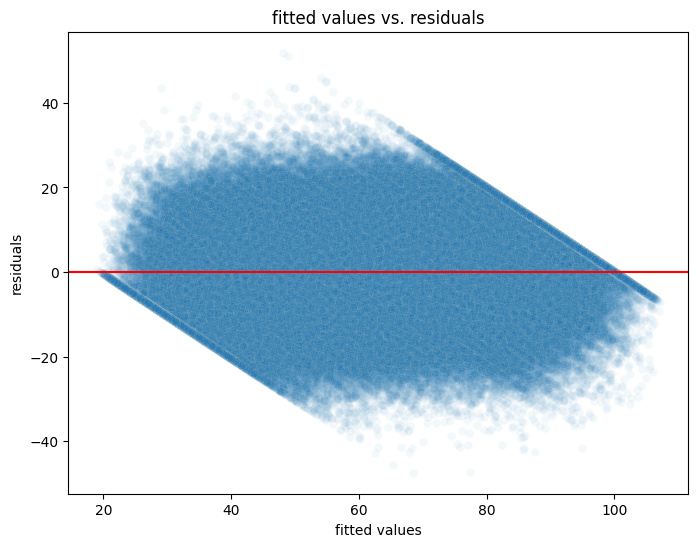

In [20]:
# fitted value vs. residuals visualization

fig = plt.figure(figsize=(8,6))
fig = sns.scatterplot(x=model_interaction.fittedvalues, y=model_interaction.resid,
                     alpha=0.05)
fig.set_title('fitted values vs. residuals')
fig.set_xlabel('fitted values')
fig.set_ylabel('residuals')

fig.axhline(0, color='red')

plt.show()

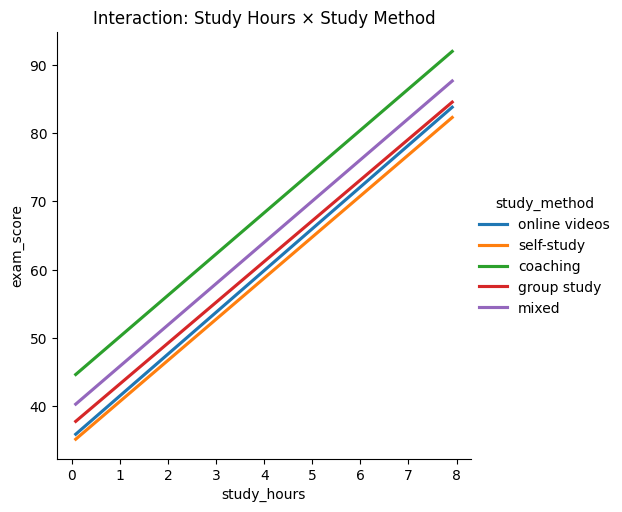

In [21]:
# interaction slopes plot

sns.lmplot(
    data=df_train,
    x="study_hours",
    y="exam_score",
    hue="study_method",
    ci=None,       
    scatter=False
)

plt.title("Interaction: Study Hours × Study Method")
plt.show()

## Conclusion

Study methods demonstrate significant differences in exam scores, but their moderating effect on the marginal returns to study time is relatively weak (Δ≈0.06). This suggests that different methods primarily influence foundational learning outcomes rather than time efficiency.

## Mechine Learning Model: XGBoost Prediction

While the regression models above focus on interpretability, a machine learning model (XGBoost) is implemented to evaluate whether nonlinear models can improve predictive performance.

Due to the large dataset size (630,000 observations), a random sample of 50,000 observations was used for initial model development and hyperparameter tuning.

The final model was then trained on the full training dataset and evaluated on the independent test set.

In [24]:
# setting X and y variables

y = df_train['exam_score']
X = df_train.drop(columns=['exam_score'])

# To ensure that dummy variables are consistent
combined = pd.concat([X, df_test], axis=0)

# get dummy variables
combined = pd.get_dummies(combined, drop_first=True)

# split train/test dataset
X_train = combined.iloc[:len(X)]
X_test = combined.iloc[len(X):]

# train/validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
# building XGBoost

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_tr, y_tr)

# model evaluation
pred_val = xgb_model.predict(X_val)

rmse = mean_squared_error(y_val, pred_val, squared=False)
r2 = r2_score(y_val, pred_val)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 8.786445178654356
R2: 0.7829263705367162


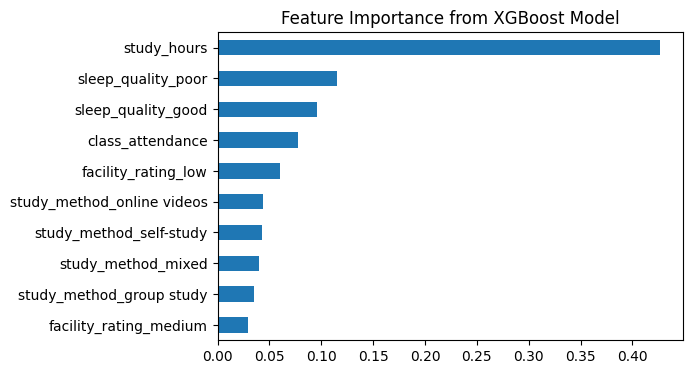

<Figure size 640x480 with 0 Axes>

In [45]:
# feature importance

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(6,4))
importance.tail(10).plot(kind="barh")

plt.title("Feature Importance from XGBoost Model")
plt.show()

# save figure

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/feature_importance.png", dpi=300, bbox_inches="tight")

In [28]:
# using df_test dataset to make a prediction

test_pred = xgb_model.predict(X_test)

predictions = pd.DataFrame({
    "id": df_test["id"],
    "predicted_exam_score": test_pred
})

predictions.head()

,id,predicted_exam_score
0,630000,72.069901
1,630001,70.135719
2,630002,87.480042
3,630003,55.891232
4,630004,47.714237


In [47]:
# save the predicting results

os.makedirs("results", exist_ok=True)
predictions.to_csv("results/xgboost_predictions.csv", index=False)

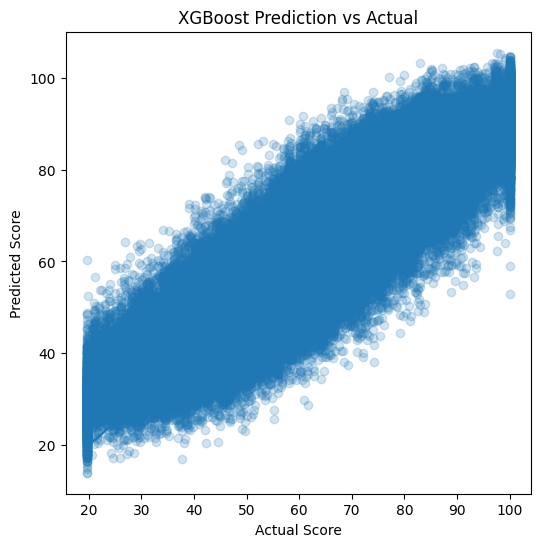

<Figure size 640x480 with 0 Axes>

In [48]:
# Prediction vs. Actual


plt.figure(figsize=(6,6))

plt.scatter(y_val, pred_val, alpha=0.2)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("XGBoost Prediction vs Actual")

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()]
)

plt.show()

# save figure
plt.savefig("figures/prediction_vs_actual.png", dpi=300, bbox_inches="tight")

In [31]:
# Comparing OLS regession vs. XGBoost
table = pd.DataFrame({'Model': ["Model1", "Model2", "Model3", 
                                "Interaction Model (Model4)", "XGBoost"],
                      'R2': [0.685, 0.709, 0.741, 0.741, r2]
                     }
                    )
table

,Model,R2
0,Model1,0.685000
1,Model2,0.709000
2,Model3,0.741000
3,Interaction Model (Model4),0.741000
4,XGBoost,0.782926


In [33]:
# building SHAP expainer 

import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_val)

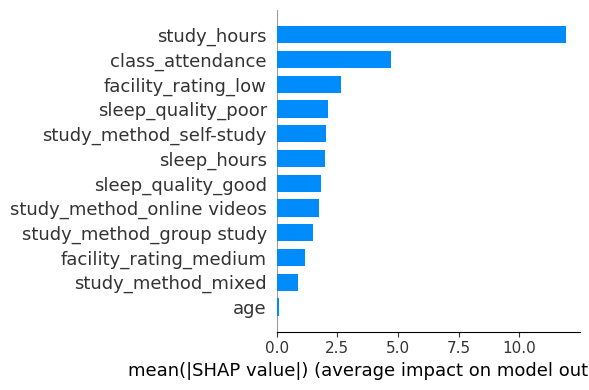

<Figure size 640x480 with 0 Axes>

In [49]:
## SHAP summary plot

shap.summary_plot(shap_values, X_val, plot_type="bar", plot_size=(6,4), max_display=12)

# save plot
plt.savefig("figures/shap_summary.png", dpi=300)

**Findings**

SHAP analysis shows that study hours and class attendance are the most influential predictors of exam performance.

The SHAP analysis confirms the feature importance results from the XGBoost model.

This finding is consistent with the regression results, suggesting that learning engagement variables play a dominant role in predicting student outcomes.

Other factors such as sleep quality and study methods also contribute to predictions but with smaller effects.

# Conclusion

Both regression and machine learning models identify `study_hours` and `class_attendance` as the most important predictors of exam performance.

Both statistical and machine learning approaches consistently identify `study_hours` and `class_attendance` as the most influential predictors of student exam performance.

The XGBoost model slightly improves predictive performance compared with OLS regression (R^2 0.783 vs 0.741), suggesting that nonlinear relationships and interaction effects exist but are relatively modest. The results suggest that student engagement variables
remain the dominant factors influencing exam outcomes.

These findings highlight the importance of consistent study habits and classroom participation for academic success.

# Limitations

This analysis is based on observational data and therefore does not
establish causal relationships. Additionally, the dataset may not
capture other important factors affecting academic performance such
as prior academic ability, motivation, or socioeconomic background.

Future work could incorporate additional variables or apply more
advanced causal inference methods.